In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import product

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    auc
)

In [82]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)


def precision_score(y_true, y_pred):
    classes = np.unique(y_true)
    precisions = []
    for cls in classes:
        TP = np.sum((y_true == cls) & (y_pred == cls))
        FP = np.sum((y_true != cls) & (y_pred == cls))
        precisions.append(0 if TP + FP == 0 else TP / (TP + FP))
    return np.mean(precisions)


def recall_score(y_true, y_pred):
    classes = np.unique(y_true)
    recalls = []
    for cls in classes:
        TP = np.sum((y_true == cls) & (y_pred == cls))
        FN = np.sum((y_true == cls) & (y_pred != cls))
        recalls.append(0 if TP + FN == 0 else TP / (TP + FN))
    return np.mean(recalls)


def f1_score(y_true, y_pred):
    classes = np.unique(y_true)
    f1s = []
    for cls in classes:
        TP = np.sum((y_true == cls) & (y_pred == cls))
        FP = np.sum((y_true != cls) & (y_pred == cls))
        FN = np.sum((y_true == cls) & (y_pred != cls))
        precision = 0 if TP + FP == 0 else TP / (TP + FP)
        recall    = 0 if TP + FN == 0 else TP / (TP + FN)
        f1 = 0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)
        f1s.append(f1)
    return np.mean(f1s)

In [83]:
def train_test_split(X, y, test_size=0.2, random_state=None,
                     shuffle=True, stratify=False):
    rng = np.random.default_rng(random_state)
    if stratify:
        classes = np.unique(y)
        train_indices, test_indices = [], []
        for c in classes:
            idx = np.where(y == c)[0]
            if shuffle:
                rng.shuffle(idx)
            n_test = int(len(idx) * test_size)
            test_indices.extend(idx[:n_test])
            train_indices.extend(idx[n_test:])
        train_indices = np.array(train_indices)
        test_indices  = np.array(test_indices)
        if shuffle:
            rng.shuffle(train_indices)
            rng.shuffle(test_indices)
    else:
        indices = np.arange(len(X))
        if shuffle:
            rng.shuffle(indices)
        n_test = int(len(X) * test_size)
        test_indices  = indices[:n_test]
        train_indices = indices[n_test:]
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]

In [84]:
class StratifiedKFold:
    def __init__(self, n_splits=10, shuffle=True, random_state=None):
        self.n_splits = n_splits
        self.shuffle = shuffle
        self.random_state = random_state

    def split(self, X, y):

        rng = np.random.default_rng(self.random_state)

        classes = np.unique(y)

        class_indices = {}

        for cls in classes:
            idx = np.where(y == cls)[0]

            if self.shuffle:
                rng.shuffle(idx)

            class_indices[cls] = np.array_split(
                idx,
                self.n_splits
            )

        for fold in range(self.n_splits):

            val_idx = []

            for cls in classes:
                val_idx.extend(
                    class_indices[cls][fold]
                )

            val_idx = np.array(val_idx)

            train_idx = np.setdiff1d(
                np.arange(len(y)),
                val_idx
            )

            yield train_idx, val_idx

In [85]:
def cross_validation_score(model_class, params, X, y, n_splits=10):

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    scores = []

    for train_idx, val_idx in skf.split(X, y):

        X_train_fold = X[train_idx].copy()
        X_val_fold = X[val_idx].copy()

        y_train_fold = y[train_idx]
        y_val_fold = y[val_idx]

        # normalização do fold
        mean = X_train_fold.mean(axis=0)
        std = X_train_fold.std(axis=0)

        std[std == 0] = 1.0

        X_train_fold = (X_train_fold - mean) / std
        X_val_fold = (X_val_fold - mean) / std

        model = model_class(**params)

        model.fit(
            X_train_fold,
            y_train_fold
        )

        y_pred = model.predict(
            X_val_fold
        )

        scores.append(
            accuracy_score(
                y_val_fold,
                y_pred
            )
        )

    return np.mean(scores)

In [86]:
data = np.loadtxt("californiabin.csv", delimiter=",")
X, y = data[:, :-1], data[:, -1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=True
)

mean = X_train.mean(axis=0)
std  = X_train.std(axis=0)
std[std == 0] = 1.0

X_train_norm = (X_train - mean) / std
X_test_norm  = (X_test  - mean) / std   

In [87]:
C_values     = [2**i for i in range(-5, 16, 2)]
gamma_values = [2**i for i in range(-15, 2, 2)] + [2**2, 2**3]

best_svm_score  = -np.inf
best_svm_params = None
svm_results     = []

print("=" * 60)
print("GRID SEARCH - SVM")
print("=" * 60)

for C, gamma in product(C_values, gamma_values):
    params = {"C": C, "gamma": gamma, "kernel": "rbf"}
    score = cross_validation_score(
        SVC,
        params,
        X_train,
        y_train
    )
    svm_results.append({"C": C, "gamma": gamma, "score": score})
    print(f"C={C:<8} gamma={gamma:<12} CV Accuracy={score:.4f}")
    if score > best_svm_score:
        best_svm_score  = score
        best_svm_params = params

best_svm = SVC(**best_svm_params, probability=True, random_state=42)
best_svm.fit(X_train_norm, y_train)

y_pred_svm = best_svm.predict(X_test_norm)
y_prob_svm = best_svm.predict_proba(X_test_norm)[:, 1]

acc_svm  = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm  = recall_score(y_test, y_pred_svm)
f1_svm   = f1_score(y_test, y_pred_svm)

fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auroc_svm = auc(fpr_svm, tpr_svm)

prec_curve_svm, rec_curve_svm, _ = precision_recall_curve(y_test, y_prob_svm)
auprc_svm = auc(rec_curve_svm, prec_curve_svm)

GRID SEARCH - SVM
C=0.03125  gamma=3.0517578125e-05 CV Accuracy=0.6081
C=0.03125  gamma=0.0001220703125 CV Accuracy=0.6081
C=0.03125  gamma=0.00048828125 CV Accuracy=0.6100
C=0.03125  gamma=0.001953125  CV Accuracy=0.6225
C=0.03125  gamma=0.0078125    CV Accuracy=0.6844
C=0.03125  gamma=0.03125      CV Accuracy=0.8006
C=0.03125  gamma=0.125        CV Accuracy=0.8219
C=0.03125  gamma=0.5          CV Accuracy=0.8119
C=0.03125  gamma=2            CV Accuracy=0.6094
C=0.03125  gamma=4            CV Accuracy=0.5556
C=0.03125  gamma=8            CV Accuracy=0.5500
C=0.125    gamma=3.0517578125e-05 CV Accuracy=0.6081
C=0.125    gamma=0.0001220703125 CV Accuracy=0.6081
C=0.125    gamma=0.00048828125 CV Accuracy=0.6100
C=0.125    gamma=0.001953125  CV Accuracy=0.6819
C=0.125    gamma=0.0078125    CV Accuracy=0.8069
C=0.125    gamma=0.03125      CV Accuracy=0.8300
C=0.125    gamma=0.125        CV Accuracy=0.8300
C=0.125    gamma=0.5          CV Accuracy=0.8300
C=0.125    gamma=2            CV Ac

In [88]:
n_estimators_values = list(range(10, 201, 10))
max_depth_values    = [4, 6, 8, 10, None]

best_rf_score  = -np.inf
best_rf_params = None
rf_results     = []

print("\n" + "=" * 60)
print("GRID SEARCH - RANDOM FOREST")
print("=" * 60)

for n_estimators, max_depth in product(n_estimators_values, max_depth_values):
    params = {"n_estimators": n_estimators, "max_depth": max_depth,
              "random_state": 42, "n_jobs": -1}
    score  = cross_validation_score(RandomForestClassifier, params, X_train, y_train)
    rf_results.append({"n_estimators": n_estimators, "max_depth": max_depth, "score": score})
    print(f"Trees={n_estimators:<4} Depth={str(max_depth):<5} CV Accuracy={score:.4f}")
    if score > best_rf_score:
        best_rf_score  = score
        best_rf_params = params

best_rf = RandomForestClassifier(**best_rf_params)
best_rf.fit(X_train_norm, y_train)

y_pred_rf = best_rf.predict(X_test_norm)
y_prob_rf = best_rf.predict_proba(X_test_norm)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auroc_rf = auc(fpr_rf, tpr_rf)

prec_curve_rf, rec_curve_rf, _ = precision_recall_curve(y_test, y_prob_rf)
auprc_rf = auc(rec_curve_rf, prec_curve_rf)


GRID SEARCH - RANDOM FOREST
Trees=10   Depth=4     CV Accuracy=0.8063
Trees=10   Depth=6     CV Accuracy=0.8231
Trees=10   Depth=8     CV Accuracy=0.8488
Trees=10   Depth=10    CV Accuracy=0.8431
Trees=10   Depth=None  CV Accuracy=0.8406
Trees=20   Depth=4     CV Accuracy=0.8213
Trees=20   Depth=6     CV Accuracy=0.8394
Trees=20   Depth=8     CV Accuracy=0.8494
Trees=20   Depth=10    CV Accuracy=0.8463
Trees=20   Depth=None  CV Accuracy=0.8556
Trees=30   Depth=4     CV Accuracy=0.8200
Trees=30   Depth=6     CV Accuracy=0.8456
Trees=30   Depth=8     CV Accuracy=0.8544
Trees=30   Depth=10    CV Accuracy=0.8538
Trees=30   Depth=None  CV Accuracy=0.8569
Trees=40   Depth=4     CV Accuracy=0.8231
Trees=40   Depth=6     CV Accuracy=0.8406
Trees=40   Depth=8     CV Accuracy=0.8544
Trees=40   Depth=10    CV Accuracy=0.8606
Trees=40   Depth=None  CV Accuracy=0.8538
Trees=50   Depth=4     CV Accuracy=0.8225
Trees=50   Depth=6     CV Accuracy=0.8438
Trees=50   Depth=8     CV Accuracy=0.8531
Trees

In [89]:
print("\n" + "=" * 60)
print("COMPARAÇÃO FINAL")
print("=" * 60)

for label, params, metrics in [
    ("SVM",           best_svm_params, (acc_svm,  prec_svm,  rec_svm,  f1_svm,  auroc_svm,  auprc_svm)),
    ("Random Forest", best_rf_params,  (acc_rf,   prec_rf,   rec_rf,   f1_rf,   auroc_rf,   auprc_rf)),
]:
    print(f"\n{label}")
    print(params)
    print(f"  Acurácia : {metrics[0]:.4f}")
    print(f"  Precisão : {metrics[1]:.4f}")
    print(f"  Revocação: {metrics[2]:.4f}")
    print(f"  F1-score : {metrics[3]:.4f}")
    print(f"  AUROC    : {metrics[4]:.4f}")
    print(f"  AUPRC    : {metrics[5]:.4f}")



COMPARAÇÃO FINAL

SVM
{'C': 2048, 'gamma': 0.0078125, 'kernel': 'rbf'}
  Acurácia : 0.8500
  Precisão : 0.8501
  Revocação: 0.8500
  F1-score : 0.8500
  AUROC    : 0.9148
  AUPRC    : 0.9018

Random Forest
{'n_estimators': 90, 'max_depth': 10, 'random_state': 42, 'n_jobs': -1}
  Acurácia : 0.8750
  Precisão : 0.8756
  Revocação: 0.8750
  F1-score : 0.8749
  AUROC    : 0.9417
  AUPRC    : 0.9496


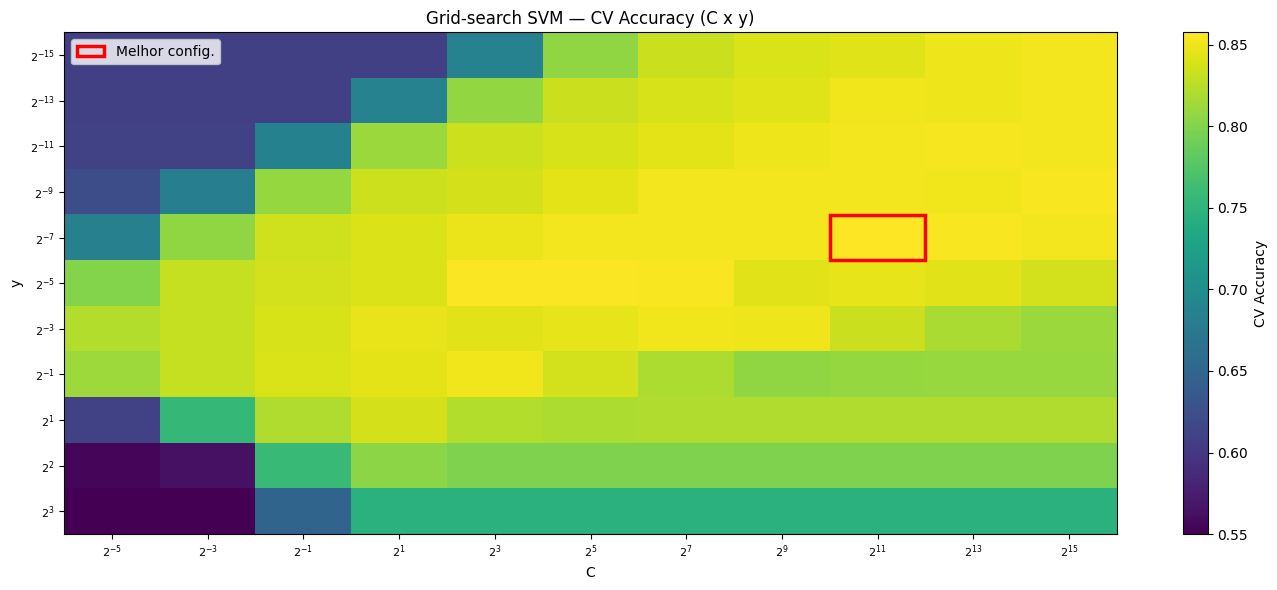

In [90]:
svm_df = pd.DataFrame(svm_results)
svm_pivot = svm_df.pivot(index="gamma", columns="C", values="score")

C_labels     = [f"$2^{{{int(np.log2(c))}}}$" for c in svm_pivot.columns]
gamma_labels = [f"$2^{{{int(np.log2(g))}}}$" for g in svm_pivot.index]

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(svm_pivot.values, aspect="auto", cmap="viridis",
               vmin=svm_pivot.values.min(), vmax=svm_pivot.values.max())
plt.colorbar(im, ax=ax, label="CV Accuracy")

ax.set_xticks(range(len(C_labels)))
ax.set_xticklabels(C_labels, fontsize=8)
ax.set_yticks(range(len(gamma_labels)))
ax.set_yticklabels(gamma_labels, fontsize=8)
ax.set_xlabel("C")
ax.set_ylabel("y")
ax.set_title("Grid-search SVM — CV Accuracy (C x y)")

best_C_idx = list(svm_pivot.columns).index(best_svm_params["C"])
best_g_idx = list(svm_pivot.index).index(best_svm_params["gamma"])
ax.add_patch(plt.Rectangle(
    (best_C_idx - 0.5, best_g_idx - 0.5), 1, 1,
    fill=False, edgecolor="red", linewidth=2.5, label="Melhor config."
))
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

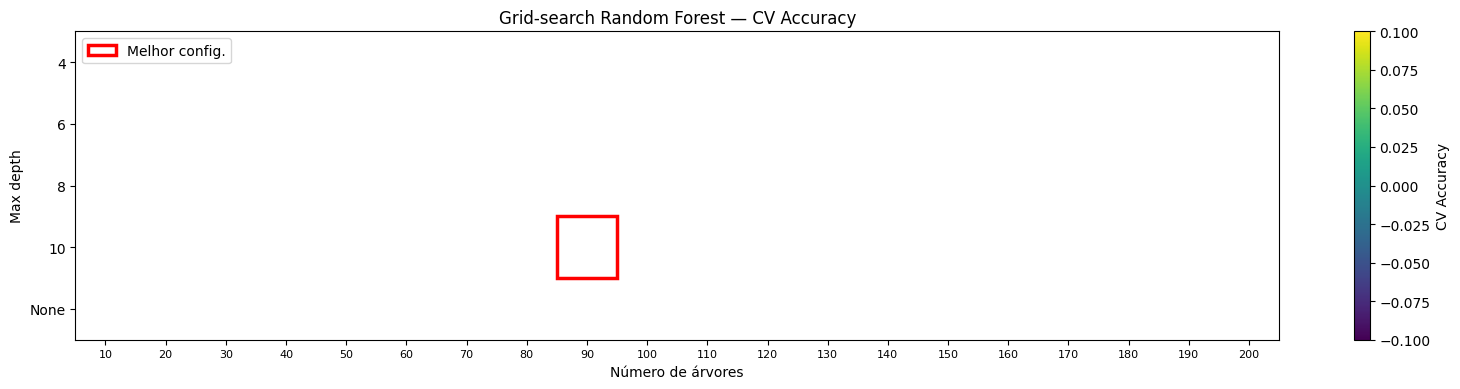

In [91]:
rf_df = pd.DataFrame(rf_results)
rf_df["max_depth_label"] = rf_df["max_depth"].apply(
    lambda x: "None" if x is None else str(x)
)
depth_order = ["4", "6", "8", "10", "None"]
rf_pivot = rf_df.pivot(index="max_depth_label", columns="n_estimators", values="score")
rf_pivot = rf_pivot.reindex(depth_order)

fig, ax = plt.subplots(figsize=(16, 4))
im = ax.imshow(rf_pivot.values, aspect="auto", cmap="viridis",
               vmin=rf_pivot.values.min(), vmax=rf_pivot.values.max())
plt.colorbar(im, ax=ax, label="CV Accuracy")

ax.set_xticks(range(len(rf_pivot.columns)))
ax.set_xticklabels(rf_pivot.columns, fontsize=8)
ax.set_yticks(range(len(rf_pivot.index)))
ax.set_yticklabels(rf_pivot.index)
ax.set_xlabel("Número de árvores")
ax.set_ylabel("Max depth")
ax.set_title("Grid-search Random Forest — CV Accuracy")

best_ne = best_rf_params["n_estimators"]
best_md = "None" if best_rf_params["max_depth"] is None else str(best_rf_params["max_depth"])
best_x  = list(rf_pivot.columns).index(best_ne)
best_y  = list(rf_pivot.index).index(best_md)
ax.add_patch(plt.Rectangle(
    (best_x - 0.5, best_y - 0.5), 1, 1,
    fill=False, edgecolor="red", linewidth=2.5, label="Melhor config."
))
ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

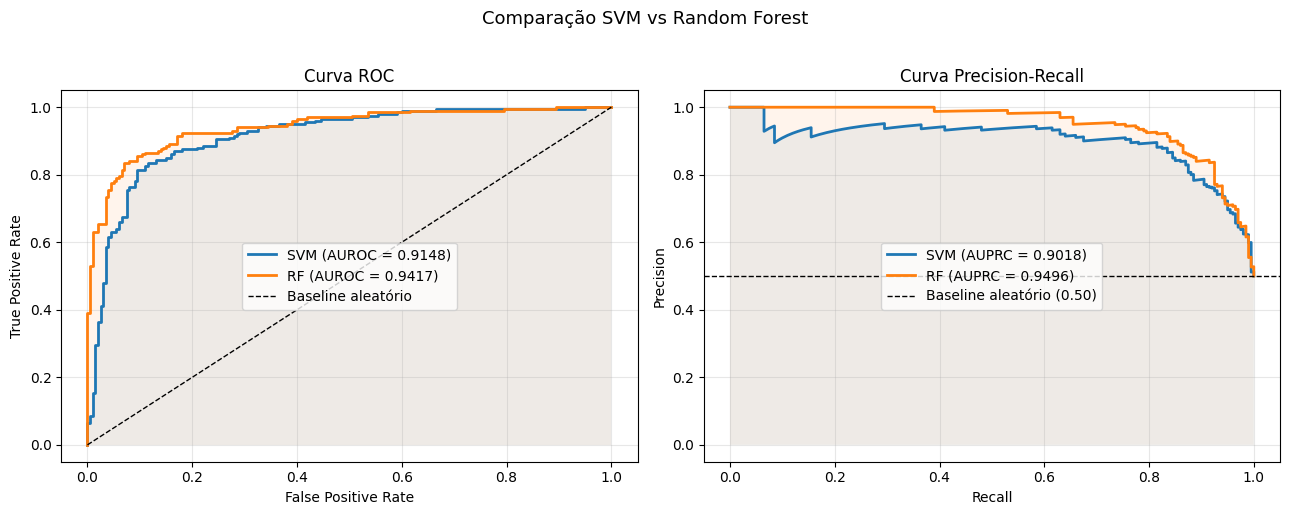

In [92]:
# Curvas ROC e Precision-Recall

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]

ax.plot(
    fpr_svm,
    tpr_svm,
    lw=2,
    label=f"SVM (AUROC = {auroc_svm:.4f})"
)

ax.plot(
    fpr_rf,
    tpr_rf,
    lw=2,
    label=f"RF (AUROC = {auroc_rf:.4f})"
)

ax.plot(
    [0, 1],
    [0, 1],
    "k--",
    lw=1,
    label="Baseline aleatório"
)

ax.fill_between(
    fpr_svm,
    tpr_svm,
    alpha=0.08
)

ax.fill_between(
    fpr_rf,
    tpr_rf,
    alpha=0.08
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Curva ROC")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]

baseline_pr = np.sum(y_test == 1) / len(y_test)

ax.plot(
    rec_curve_svm,
    prec_curve_svm,
    lw=2,
    label=f"SVM (AUPRC = {auprc_svm:.4f})"
)

ax.plot(
    rec_curve_rf,
    prec_curve_rf,
    lw=2,
    label=f"RF (AUPRC = {auprc_rf:.4f})"
)

ax.axhline(
    baseline_pr,
    color="k",
    linestyle="--",
    lw=1,
    label=f"Baseline aleatório ({baseline_pr:.2f})"
)

ax.fill_between(
    rec_curve_svm,
    prec_curve_svm,
    alpha=0.08
)

ax.fill_between(
    rec_curve_rf,
    prec_curve_rf,
    alpha=0.08
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Curva Precision-Recall")
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle(
    "Comparação SVM vs Random Forest",
    fontsize=13,
    y=1.02
)

plt.tight_layout()

plt.show()